In [1]:
import pandas as pd

df = pd.read_csv('c:/data/ozone/ozone2.csv')
df.head()

,Month,Day,Solar.R,Wind,Temp,Ozone,Result
0,5,1,190.000000,7.4,67,41,0
1,5,2,118.000000,8.0,72,36,0
2,5,3,149.000000,12.6,74,12,0
3,5,4,313.000000,11.5,62,18,0
4,5,5,185.931507,14.3,56,42,1


In [2]:
df['Result'].value_counts()

Result
1    81
0    72
Name: count, dtype: int64

C:\Users\Admin\AppData\Local\Temp\ipykernel_15480\441256391.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Result', data=df, palette=colors)


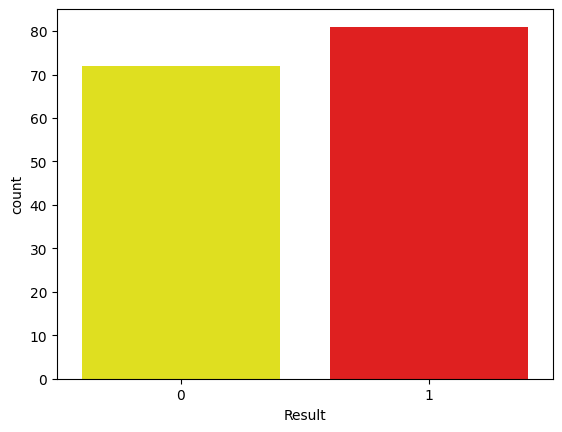

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

colors = ['yellow', 'red']
sns.countplot(x='Result', data=df, palette=colors)
cols = ['Solar.R', 'Wind', 'Temp']
X = df[cols]
y = df['Result']

array([[<Axes: xlabel='Solar.R', ylabel='Solar.R'>,
        <Axes: xlabel='Wind', ylabel='Solar.R'>,
        <Axes: xlabel='Temp', ylabel='Solar.R'>],
       [<Axes: xlabel='Solar.R', ylabel='Wind'>,
        <Axes: xlabel='Wind', ylabel='Wind'>,
        <Axes: xlabel='Temp', ylabel='Wind'>],
       [<Axes: xlabel='Solar.R', ylabel='Temp'>,
        <Axes: xlabel='Wind', ylabel='Temp'>,
        <Axes: xlabel='Temp', ylabel='Temp'>]], dtype=object)

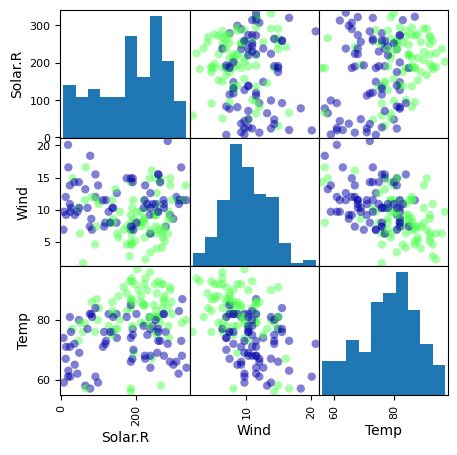

In [4]:
import mglearn
#산점도행렬
pd.plotting.scatter_matrix(X, c=y, figsize=(5, 5), marker='o', cmap=mglearn.cm3)

In [5]:
#언더샘플링
from imblearn.under_sampling import RandomUnderSampler

X_sample, y_sample = RandomUnderSampler(random_state=0).fit_resample(X, y)
X_samp = pd.DataFrame(data=X_sample, columns=cols)
y_samp = pd.DataFrame(data=y_sample, columns=['Result'])
df_samp = pd.concat([X_samp, y_samp], axis=1)
df_samp.Result.value_counts()

Result
0    72
1    72
Name: count, dtype: int64

In [6]:
X = X_samp[cols]
y = y_samp['Result']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

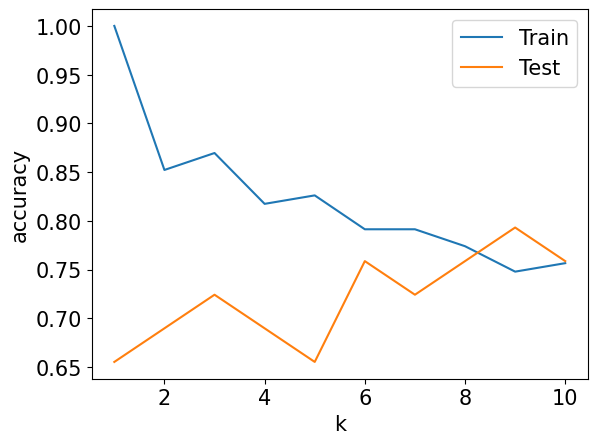

In [9]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

train_rate = []
test_rate = []

neighbors = range(1, 11)
for n in neighbors:
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train_scaled, y_train)
    train_rate.append(knn.score(X_train_scaled, y_train))
    test_rate.append(knn.score(X_test_scaled, y_test))

plt.rcParams['font.size'] = 15
plt.plot(neighbors, train_rate, label='Train')
plt.plot(neighbors, test_rate, label='Test')
plt.ylabel('accuracy')
plt.xlabel('k')
plt.legend()

In [17]:
import numpy as np

max_rate = max(test_rate)  #최댓값
print(max_rate)
idx = np.argmax(test_rate)  #최댓값의 인덱스
print(idx)
print('최적의 k:', idx + 1)

0.7931034482758621
8
최적의 k: 9


In [18]:
model = KNeighborsClassifier(n_neighbors=9)
model.fit(X_train_scaled, y_train)
pred = model.predict(X_test_scaled)
print('학습용:', model.score(X_train_scaled, y_train))
print('검증용:', model.score(X_test_scaled, y_test))

학습용: 0.7478260869565218
검증용: 0.7931034482758621


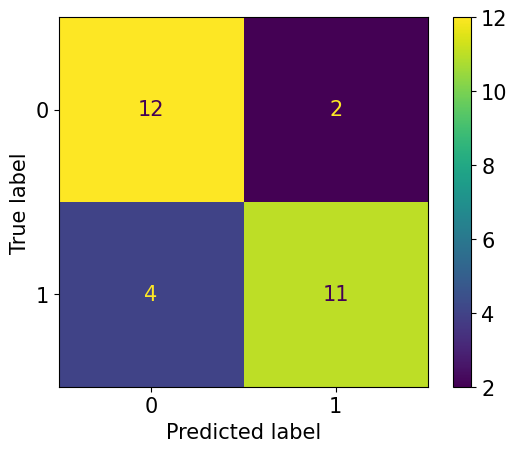

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, pred), display_labels=model.classes_).plot()